<a href="https://colab.research.google.com/github/Fatema5007/Deep-Learning-Foundations/blob/main/CNN_with_%26_without_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Verify GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type != 'cuda':
    print("Warning: Please switch your runtime to T4 GPU for faster training!")

Using device: cuda


In [7]:
# 1. Standard transformation (No Augmentation)
transform_standard = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. Augmented transformation (With Horizontal Flip, Rotation, and Zoom)
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Downloading and preparing datasets...")
# Base Test Loader (used for evaluating both models)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_standard)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Loader 1: Without Augmentation
trainset_no_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_standard)
trainloader_no_aug = torch.utils.data.DataLoader(trainset_no_aug, batch_size=64, shuffle=True, num_workers=2)

# Loader 2: With Augmentation
trainset_with_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented)
trainloader_with_aug = torch.utils.data.DataLoader(trainset_with_aug, batch_size=64, shuffle=True, num_workers=2)

print("\nData loading complete! Ready to train.")


Data loading complete! Ready to train.


In [8]:
def run_experiment(train_loader, test_loader, epochs=8):
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_accs = []
    test_accs = [] # Array to track evaluation score per epoch

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_acc = 100.0 * correct / total
        train_accs.append(epoch_train_acc)

        # Evaluation step on test set right after the epoch ends
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        epoch_test_acc = 100.0 * test_correct / test_total
        test_accs.append(epoch_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] -> Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

    return train_accs, test_accs

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 8x8
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))  # 4x4
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [11]:
print("--- Training CNN Model 1: WITHOUT Augmentation ---")
no_aug_train, no_aug_test = run_experiment(trainloader_no_aug, testloader, epochs=8)

# Fixed labels to clearly distinguish Train vs Test metrics
print(f"Final Train Accuracy (No Augmentation): {no_aug_train[-1]:.2f}%\n")
print(f"Final Test Accuracy (No Augmentation): {no_aug_test[-1]:.2f}%\n")

--- Training CNN Model 1: WITHOUT Augmentation ---
Epoch [1/8] -> Train Acc: 49.32% | Test Acc: 59.89%
Epoch [2/8] -> Train Acc: 66.30% | Test Acc: 69.28%
Epoch [3/8] -> Train Acc: 73.98% | Test Acc: 73.72%
Epoch [4/8] -> Train Acc: 78.97% | Test Acc: 74.86%
Epoch [5/8] -> Train Acc: 83.02% | Test Acc: 75.39%
Epoch [6/8] -> Train Acc: 86.11% | Test Acc: 75.18%
Epoch [7/8] -> Train Acc: 89.34% | Test Acc: 76.76%
Epoch [8/8] -> Train Acc: 91.79% | Test Acc: 76.38%
Final Train Accuracy (No Augmentation): 91.79%

Final Test Accuracy (No Augmentation): 76.38%



In [12]:
print("--- Training CNN Model 2: WITH Data Augmentation ---")
with_aug_train, with_aug_test = run_experiment(trainloader_with_aug, testloader, epochs=8)

# Fixed labels to clearly distinguish Train vs Test metrics
print(f"Final Train Accuracy (With Augmentation): {with_aug_train[-1]:.2f}%\n")
print(f"Final Test Accuracy (With Augmentation): {with_aug_test[-1]:.2f}%\n")

--- Training CNN Model 2: WITH Data Augmentation ---
Epoch [1/8] -> Train Acc: 45.70% | Test Acc: 57.73%
Epoch [2/8] -> Train Acc: 60.05% | Test Acc: 67.31%
Epoch [3/8] -> Train Acc: 66.42% | Test Acc: 69.74%
Epoch [4/8] -> Train Acc: 70.02% | Test Acc: 73.62%
Epoch [5/8] -> Train Acc: 72.51% | Test Acc: 73.48%
Epoch [6/8] -> Train Acc: 74.19% | Test Acc: 73.79%
Epoch [7/8] -> Train Acc: 75.65% | Test Acc: 77.21%
Epoch [8/8] -> Train Acc: 76.51% | Test Acc: 77.62%
Final Train Accuracy (With Augmentation): 76.51%

Final Test Accuracy (With Augmentation): 77.62%



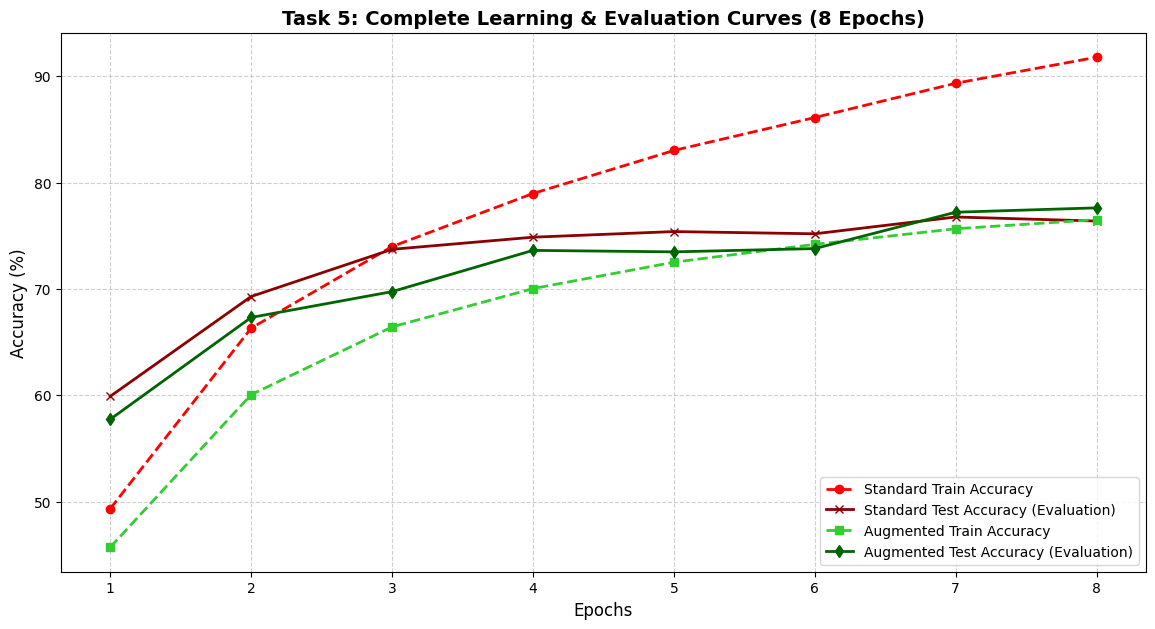


               FINAL DATA AUGMENTATION SUMMARY TABLE               
Experiment Configuration     | Final Train Acc    | Final Test Acc 
----------------------------------------------------------------------
Without Augmentation         | 91.79%            | 76.38%
WITH Data Augmentation       | 76.51%            | 77.62%


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# 1. Standard Model Curves (Without Augmentation)
plt.plot(range(1, 9), no_aug_train, color='red', linestyle='--', marker='o', label='Standard Train Accuracy', linewidth=2)
plt.plot(range(1, 9), no_aug_test, color='darkred', linestyle='-', marker='x', label='Standard Test Accuracy (Evaluation)', linewidth=2)

# 2. Augmented Model Curves (With Data Augmentation)
plt.plot(range(1, 9), with_aug_train, color='limegreen', linestyle='--', marker='s', label='Augmented Train Accuracy', linewidth=2)
plt.plot(range(1, 9), with_aug_test, color='darkgreen', linestyle='-', marker='d', label='Augmented Test Accuracy (Evaluation)', linewidth=2)

plt.title('Task 5: Complete Learning & Evaluation Curves (8 Epochs)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n" + "="*70)
print("               FINAL DATA AUGMENTATION SUMMARY TABLE               ")
print("="*70)
print(f"{'Experiment Configuration':<28} | {'Final Train Acc':<18} | {'Final Test Acc':<15}")
print("-"*70)
print(f"{'Without Augmentation':<28} | {no_aug_train[-1]:.2f}%{' ':<11} | {no_aug_test[-1]:.2f}%")
print(f"{'WITH Data Augmentation':<28} | {with_aug_train[-1]:.2f}%{' ':<11} | {with_aug_test[-1]:.2f}%")
print("="*70)